# ICU Mortality Prediction - Exploratory Data Analysis

## Author
Siva Ram Potluri

## Project Overview
This notebook presents the exploratory data analysis (EDA) and data preparation process for the ICU mortality prediction project.

The purpose of this analysis is to:
- understand the structure of the original dataset
- examine missing values and class imbalance
- study APACHE and non-APACHE variables
- perform feature selection
- create a final curated dataset for machine learning modeling

The original dataset comes from the WiDS Datathon ICU Mortality Prediction challenge and contains de-identified ICU patient records.

The final goal of the project is to predict whether a patient dies during the hospital stay using clinical measurements collected during the first 24 hours of ICU admission.

In [1]:
# Import required libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_style("whitegrid")

## 1. Load the Original Dataset

In this section, the original ICU dataset is loaded. This dataset contains a large number of demographic, physiological, laboratory, and APACHE-related variables.

This notebook begins with the original dataset because EDA should first examine the raw data before creating the final modeling dataset.

In [2]:
# Load the original dataset
df = pd.read_csv("/content/training_v2.csv")

# Preview the first few rows
df.head()

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_invasive_max,d1_diasbp_invasive_min,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_invasive_max,d1_mbp_invasive_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_invasive_max,d1_sysbp_invasive_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_invasive_max,h1_diasbp_invasive_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_invasive_max,h1_mbp_invasive_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_invasive_max,h1_sysbp_invasive_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_inr_max,d1_inr_min,d1_lactate_max,d1_lactate_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_albumin_max,h1_albumin_min,h1_bilirubin_max,h1_bilirubin_min,h1_bun_max,h1_bun_min,h1_calcium_max,h1_calcium_min,h1_creatinine_max,h1_creatinine_min,h1_glucose_max,h1_glucose_min,h1_hco3_max,h1_hco3_min,h1_hemaglobin_max,h1_hemaglobin_min,h1_hematocrit_max,h1_hematocrit_min,h1_inr_max,h1_inr_min,h1_lactate_max,h1_lactate_min,h1_platelets_max,h1_platelets_min,h1_potassium_max,h1_potassium_min,h1_sodium_max,h1_sodium_min,h1_wbc_max,h1_wbc_min,d1_arterial_pco2_max,d1_arterial_pco2_min,d1_arterial_ph_max,d1_arterial_ph_min,d1_arterial_po2_max,d1_arterial_po2_min,d1_pao2fio2ratio_max,d1_pao2fio2ratio_min,h1_arterial_pco2_max,h1_arterial_pco2_min,h1_arterial_ph_max,h1_arterial_ph_min,h1_arterial_po2_max,h1_arterial_po2_min,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,92,admit,CTICU,0.541667,0,73.9,2.3,113.0,502.01,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,46.0,32.0,68.0,37.0,68.0,37.0,119.0,72.0,66.0,40.0,89.0,46.0,89.0,46.0,34.0,10.0,100.0,74.0,122.0,64.0,131.0,73.0,131.0,73.0,39.9,37.2,NaN,NaN,68.0,63.0,68.0,63.0,119.0,108.0,NaN,NaN,86.0,85.0,86.0,85.0,26.0,18.0,100.0,74.0,NaN,NaN,131.0,115.0,131.0,115.0,39.5,37.5,2.3,2.3,0.4,0.4,31.0,30.0,8.5,7.4,2.51,2.23,168.0,109.0,19.0,15.0,8.9,8.9,27.4,27.4,NaN,NaN,1.3,1.0,233.0,233.0,4.0,3.4,136.0,134.0,14.1,14.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,90,admit,Med-Surg ICU,0.927778,0,70.2,NaN,1

## 2. Dataset Overview

This section examines the size, structure, and basic characteristics of the original dataset.

In [3]:
# Check dataset shape
print("Dataset shape:", df.shape)

Dataset shape: (91713, 186)


In [4]:
# View all column names
df.columns.tolist()

['encounter_id',
 'patient_id',
 'hospital_id',
 'hospital_death',
 'age',
 'bmi',
 'elective_surgery',
 'ethnicity',
 'gender',
 'height',
 'hospital_admit_source',
 'icu_admit_source',
 'icu_id',
 'icu_stay_type',
 'icu_type',
 'pre_icu_los_days',
 'readmission_status',
 'weight',
 'albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache',
 'd1_diasbp_invasive_max',
 'd1_diasbp_invasive_min',
 'd1_diasbp_max',
 'd1_diasbp_min',
 'd1_diasbp_noninvasive_max',
 'd1_diasbp_noninvasive_min',
 'd1_heartrate_m

In [5]:
# Inspect data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Columns: 186 entries, encounter_id to apache_2_bodysystem
dtypes: float64(170), int64(8), object(8)
memory usage: 130.1+ MB


In [6]:
# Summary statistics for numeric variables
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
encounter_id,91713.0,65606.079280,37795.088538,1.000000,32852.000000,65665.000000,98342.000000,131051.000000
patient_id,91713.0,65537.131464,37811.252183,1.000000,32830.000000,65413.000000,98298.000000,131051.000000
hospital_id,91713.0,105.669262,62.854406,2.000000,47.000000,109.000000,161.000000,204.000000
hospital_death,91713.0,0.086302,0.280811,0.000000,0.000000,0.000000,0.000000,1.000000
age,87485.0,62.309516,16.775119,16.000000,52.000000,65.000000,75.000000,89.000000
bmi,88284.0,29.185818,8.275142,14.844926,23.641975,27.654655,32.930206,67.814990
elective_surgery,91713.0,0.183736,0.387271,0.000000,0.000000,0.000000,0.000000,1.000000
height,90379.0,169.641588,10.795378,137.200000,162.500000,170.100000,177.800000,195.590000
icu_id,91713.0,508.357692,228.989661,82.000000,369.000000,504.000000,679.000000,927.000000
pre_icu_los_days,91713.0,0.835766,2.487756,-24.947222,0.035417,0.138889,0.409028,159.090972


### Interpretation

The original dataset contains a large number of variables and represents ICU patient encounters. Each row corresponds to one ICU patient encounter, and the dataset includes demographic features, laboratory measurements, vital signs, APACHE-derived severity indicators, and the mortality outcome variable.

Because the original dataset contains many variables and substantial missing data, careful data preparation is needed before model development.

## 3. APACHE vs Non-APACHE Variables

A major focus of this project is comparing APACHE-derived features with non-APACHE clinical measurements.

APACHE stands for **Acute Physiology and Chronic Health Evaluation**. It is a clinical severity scoring system used in ICUs to estimate mortality risk using the worst physiological values observed during the first 24 hours of ICU admission.

This section separates APACHE-related columns from non-APACHE columns.

In [7]:
# Identify APACHE-related columns
apache_cols = [c for c in df.columns if "apache" in c.lower()]

# Identify non-APACHE columns
non_apache_cols = [c for c in df.columns if "apache" not in c.lower()]

print("Total columns:", df.shape[1])
print("APACHE columns:", len(apache_cols))
print("Non-APACHE columns:", len(non_apache_cols))

Total columns: 186
APACHE columns: 32
Non-APACHE columns: 154


In [8]:
# Display APACHE columns
apache_cols

['albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache',
 'apache_4a_hospital_death_prob',
 'apache_4a_icu_death_prob',
 'apache_3j_bodysystem',
 'apache_2_bodysystem']

### Interpretation

The dataset contains a substantial number of APACHE-related variables. These variables are important because they summarize worst-case physiological conditions and reflect traditional ICU severity scoring.

The remaining columns are non-APACHE variables, including demographic measurements, raw physiological summaries, and laboratory data.

## 4. Target Variable Analysis

The target variable for this project is `hospital_death`.

- `0` = the patient survived the hospital stay
- `1` = the patient died during the hospital stay

This section examines the class distribution of the target variable.

In [9]:
# Count target values
df["hospital_death"].value_counts()

,count
hospital_death,
0,83798
1,7915


In [10]:
# Percentage distribution of target values
(df["hospital_death"].value_counts(normalize=True) * 100).round(2)

,proportion
hospital_death,
0,91.37
1,8.63


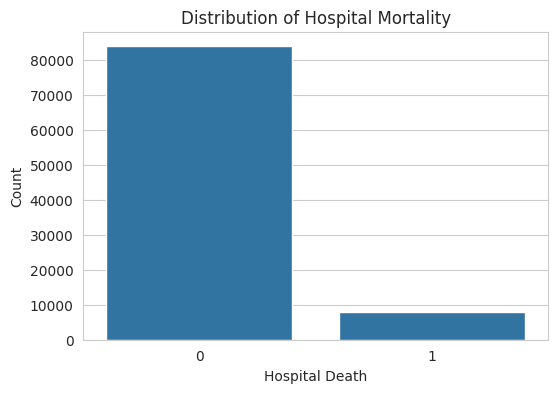

In [11]:
# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="hospital_death", data=df)
plt.title("Distribution of Hospital Mortality")
plt.xlabel("Hospital Death")
plt.ylabel("Count")
plt.show()

### Interpretation

The target variable is imbalanced, with many more survivors than deaths. This is expected in real-world ICU datasets. Because of this class imbalance, model evaluation should not rely only on accuracy. Instead, metrics such as ROC-AUC, precision, recall, and F1-score will be more informative.

## 5. Missing Value Analysis

Clinical datasets often contain missing values because not all patients undergo the same laboratory tests or measurements.

This section evaluates the extent of missing data in the original dataset.

In [12]:
# Count missing values per column
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts.head(20)

,0
h1_bilirubin_min,84619
h1_bilirubin_max,84619
h1_lactate_min,84369
h1_lactate_max,84369
h1_albumin_max,83824
h1_albumin_min,83824
h1_pao2fio2ratio_min,80195
h1_pao2fio2ratio_max,80195
h1_arterial_ph_max,76424
h1_arterial_ph_min,76424


In [13]:
# Percentage of missing values per column
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent.head(20)

,0
h1_bilirubin_min,92.265001
h1_bilirubin_max,92.265001
h1_lactate_min,91.992411
h1_lactate_max,91.992411
h1_albumin_max,91.398166
h1_albumin_min,91.398166
h1_pao2fio2ratio_min,87.441257
h1_pao2fio2ratio_max,87.441257
h1_arterial_ph_max,83.329517
h1_arterial_ph_min,83.329517


In [14]:
# Overall missingness in the original dataset
overall_missing_pct = df.isnull().mean().mean() * 100
print(f"Overall missingness in original dataset: {overall_missing_pct:.2f}%")

Overall missingness in original dataset: 33.67%


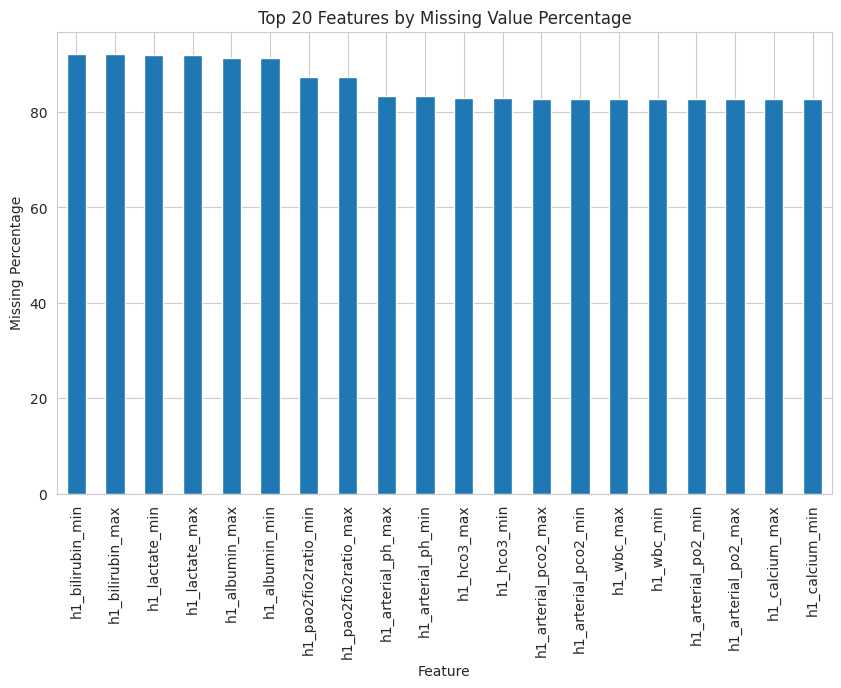

In [15]:
# Plot top 20 features with highest missingness
plt.figure(figsize=(10, 6))
missing_percent.head(20).plot(kind="bar")
plt.title("Top 20 Features by Missing Value Percentage")
plt.ylabel("Missing Percentage")
plt.xlabel("Feature")
plt.xticks(rotation=90)
plt.show()

### Interpretation

The original dataset contains substantial missing data, which is common in ICU data. Missingness occurs because laboratory tests and physiological measurements are collected based on patient condition and clinician judgment rather than a fixed protocol.

This level of missingness motivates the use of imputation during later modeling steps.

## 6. Explore Selected Clinical Variables

To better understand the dataset, a few representative variables are explored visually. These plots help identify skewness, spread, and potential outliers in important physiological features.

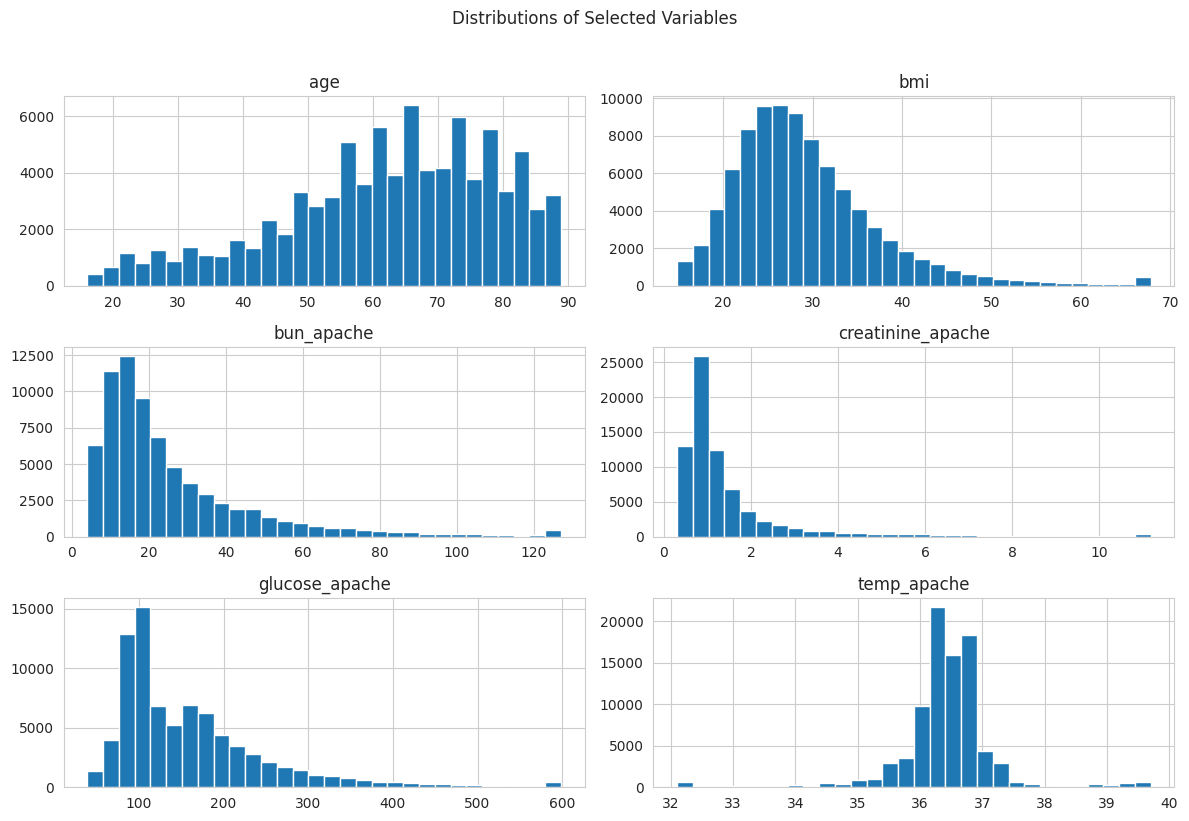

In [16]:
# Select a few representative variables for quick distribution analysis
selected_vars = [
    "age",
    "bmi",
    "bun_apache",
    "creatinine_apache",
    "glucose_apache",
    "temp_apache"
]

# Plot histograms for selected variables
df[selected_vars].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distributions of Selected Variables", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

Several laboratory and physiological variables show skewed distributions, especially BUN, creatinine, and glucose. This is expected in ICU settings because abnormal physiological values are more common among critically ill patients.

## 7. Relationship Between Key Features and Mortality

This section compares selected physiological variables across the mortality outcome. This can help identify variables that appear clinically associated with hospital death.

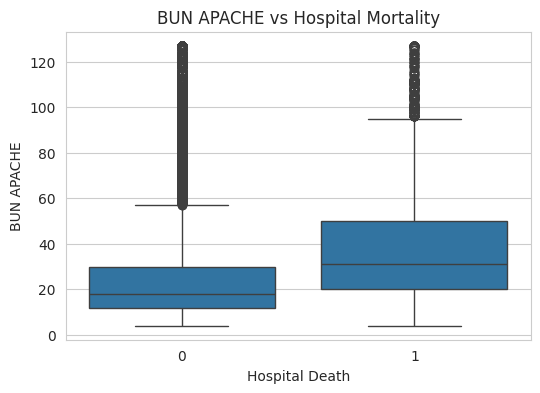

In [17]:
# Boxplot for BUN APACHE vs mortality
plt.figure(figsize=(6, 4))
sns.boxplot(x="hospital_death", y="bun_apache", data=df)
plt.title("BUN APACHE vs Hospital Mortality")
plt.xlabel("Hospital Death")
plt.ylabel("BUN APACHE")
plt.show()

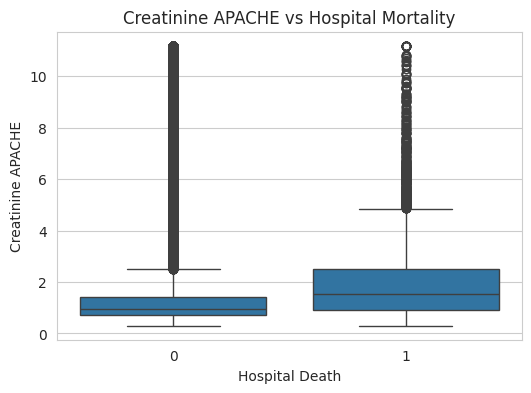

In [18]:
# Boxplot for Creatinine APACHE vs mortality
plt.figure(figsize=(6, 4))
sns.boxplot(x="hospital_death", y="creatinine_apache", data=df)
plt.title("Creatinine APACHE vs Hospital Mortality")
plt.xlabel("Hospital Death")
plt.ylabel("Creatinine APACHE")
plt.show()

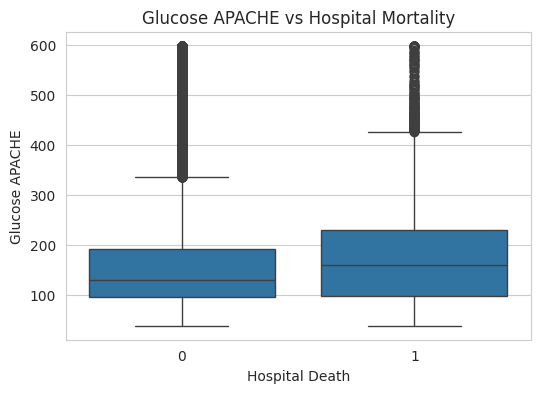

In [19]:
# Boxplot for Glucose APACHE vs mortality
plt.figure(figsize=(6, 4))
sns.boxplot(x="hospital_death", y="glucose_apache", data=df)
plt.title("Glucose APACHE vs Hospital Mortality")
plt.xlabel("Hospital Death")
plt.ylabel("Glucose APACHE")
plt.show()

### Interpretation

The boxplots suggest that patients who died during the hospital stay tend to have more abnormal physiological values. In particular, kidney-related indicators such as BUN and creatinine appear higher among non-survivors, which supports their clinical relevance.

## 8. Data Cleaning and Preparation Plan

Before modeling, the original dataset must be cleaned and reduced to a focused set of features.

The following preparation steps are used in this project:

1. Separate APACHE and non-APACHE variables
2. Remove identifier columns
3. Exclude APACHE mortality prediction outputs to prevent data leakage
4. Rank APACHE features using Random Forest feature importance
5. Select top APACHE variables
6. Match each APACHE feature with a corresponding non-APACHE physiological feature
7. Create the final modeling dataset

### Why APACHE Prediction Outputs Are Removed

The columns `apache_4a_hospital_death_prob` and `apache_4a_icu_death_prob` are direct mortality predictions produced by the APACHE IV scoring system.

These variables are excluded because they would introduce **data leakage**. Including them would make the machine learning task unfair since the model would already be given a precomputed mortality prediction.

In [20]:
# Define key columns
TARGET = "hospital_death"
ID_COLS = ["encounter_id", "patient_id", "hospital_id", "icu_id"]

# APACHE outputs to exclude due to leakage risk
LEAKY_APACHE_OUTPUTS = {
    "apache_4a_hospital_death_prob",
    "apache_4a_icu_death_prob"
}

# Create APACHE feature pool excluding leakage columns
apache_feature_pool = [c for c in apache_cols if c not in LEAKY_APACHE_OUTPUTS]

# Create non-APACHE feature pool excluding IDs and target
non_apache_feature_pool = [
    c for c in df.columns
    if c not in apache_cols + ID_COLS + [TARGET]
]

print("APACHE feature pool size:", len(apache_feature_pool))
print("Non-APACHE feature pool size:", len(non_apache_feature_pool))

APACHE feature pool size: 30
Non-APACHE feature pool size: 149


## 9. Feature Selection Using Random Forest

To create a smaller and more interpretable modeling dataset, the top APACHE features are selected using Random Forest feature importance.

Random Forest was chosen because it can capture nonlinear relationships and interactions better than simple correlation-based selection.

In [21]:
# Prepare APACHE-only feature matrix
X_apache = df[apache_feature_pool].copy()
y = df[TARGET].copy()

# Separate numeric and categorical APACHE columns
num_apache = X_apache.select_dtypes(include=[np.number]).columns.tolist()
cat_apache = [c for c in X_apache.columns if c not in num_apache]

print("Numeric APACHE columns:", len(num_apache))
print("Categorical APACHE columns:", len(cat_apache))

Numeric APACHE columns: 28
Categorical APACHE columns: 2


In [22]:
# Preprocessing for numeric APACHE columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing for categorical APACHE columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine preprocessing steps
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_apache),
        ("cat", categorical_transformer, cat_apache),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Random Forest model for feature ranking
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Build pipeline
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

# Fit the model
model.fit(X_apache, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['albumin_apache',
                                                   'apache_2_diagnosis',
                                                   'apache_3j_diagnosis',
                                                   'apache_post_operative',
                                                   'arf_apache',
                                                   'bilirubin_apache',
                                                   'bun_apache',
                                                   'creatinine_apache',
                                                   'fio2_apache',
                                                   'gcs_eyes_apache',
                                                   'gcs_motor_apache',
                                                   'gcs_unable_apach...
                                                   'ventilated_apache',
                                                   'wbc_apache']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['apache_3j_bodysystem',
                                                   'apache_2_bodysystem'])],
                                   verbose_feature_names_out=False)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=400, n_jobs=-1,
                                        random_state=42))])

In [23]:
# Get transformed feature names and importances
feat_names = model.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(
    model.named_steps["rf"].feature_importances_,
    index=feat_names
).sort_values(ascending=False)

# Display top transformed features
importances.head(20)

,0
bun_apache,0.066225
map_apache,0.059572
heart_rate_apache,0.057266
apache_3j_diagnosis,0.056918
creatinine_apache,0.054189
ventilated_apache,0.051674
resprate_apache,0.048868
temp_apache,0.048691
glucose_apache,0.045520
apache_2_diagnosis,0.041897


In [24]:
# Aggregate transformed feature importances back to original APACHE columns
apache_importance = {}

for fname, imp in importances.items():
    for col in apache_feature_pool:
        if fname == col or fname.startswith(col + "_"):
            apache_importance[col] = apache_importance.get(col, 0) + imp

apache_importance = pd.Series(apache_importance).sort_values(ascending=False)
apache_importance.head(15)

,0
bun_apache,0.066225
map_apache,0.059572
heart_rate_apache,0.057266
apache_3j_diagnosis,0.056918
creatinine_apache,0.054189
ventilated_apache,0.051674
resprate_apache,0.048868
temp_apache,0.048691
glucose_apache,0.045520
apache_2_diagnosis,0.041897


### Interpretation

The Random Forest feature importance results identify the most informative APACHE variables for predicting hospital mortality. These variables will be used to construct the final reduced dataset.

In [25]:
# Select top 8 APACHE features
top_8_apache = apache_importance.head(8).index.tolist()

print("Top 8 APACHE features:")
top_8_apache

Top 8 APACHE features:


['bun_apache',
 'map_apache',
 'heart_rate_apache',
 'apache_3j_diagnosis',
 'creatinine_apache',
 'ventilated_apache',
 'resprate_apache',
 'temp_apache']

## 10. Match APACHE Features with Non-APACHE Counterparts

For each selected APACHE feature, a corresponding non-APACHE clinical summary is chosen. The goal is to create feature pairs that compare APACHE-based worst-case abstraction with raw clinical measurements.

Preference is given to day-1 summary statistics such as:
- `d1_*_mean`
- `d1_*_max`
- `d1_*_min`
followed by first-hour summaries if needed.

In [26]:
# Function to choose the best non-APACHE counterpart
def pick_best_match(candidates):
    if not candidates:
        return None

    preferences = [
        lambda c: c.startswith("d1_") and c.endswith("_mean"),
        lambda c: c.startswith("d1_") and c.endswith("_max"),
        lambda c: c.startswith("d1_") and c.endswith("_min"),
        lambda c: c.startswith("h1_") and c.endswith("_mean"),
        lambda c: c.startswith("h1_") and c.endswith("_max"),
        lambda c: c.startswith("h1_") and c.endswith("_min"),
    ]

    for rule in preferences:
        matches = [c for c in candidates if rule(c)]
        if matches:
            return sorted(matches, key=len)[0]

    return sorted(candidates, key=len)[0]

In [27]:
# Match APACHE features to non-APACHE counterparts
apache_to_non = {}

for a in top_8_apache:
    base = a.replace("_apache", "")
    pattern = re.compile(rf"(^|_)({re.escape(base)})(_|$)", re.IGNORECASE)
    candidates = [c for c in non_apache_feature_pool if pattern.search(c)]
    apache_to_non[a] = pick_best_match(candidates)

apache_to_non

{'bun_apache': 'd1_bun_max',
 'map_apache': None,
 'heart_rate_apache': None,
 'apache_3j_diagnosis': None,
 'creatinine_apache': 'd1_creatinine_max',
 'ventilated_apache': None,
 'resprate_apache': 'd1_resprate_max',
 'temp_apache': 'd1_temp_max'}

In [28]:
# Display APACHE -> non-APACHE pairs in a table
pair_df = pd.DataFrame({
    "APACHE Feature": list(apache_to_non.keys()),
    "Non-APACHE Counterpart": list(apache_to_non.values())
})

pair_df

,APACHE Feature,Non-APACHE Counterpart
0,bun_apache,d1_bun_max
1,map_apache,None
2,heart_rate_apache,None
3,apache_3j_diagnosis,None
4,creatinine_apache,d1_creatinine_max
5,ventilated_apache,None
6,resprate_apache,d1_resprate_max
7,temp_apache,d1_temp_max


### Interpretation

The paired feature design supports the main project objective: comparing APACHE-derived severity features with corresponding non-APACHE physiological summaries.

## 11. Create the Final Dataset

The final modeling dataset is created using:
- 8 APACHE features
- 8 corresponding non-APACHE features
- 1 target variable (`hospital_death`)

In [29]:
# Build final feature list
final_apache = list(apache_to_non.keys())
final_non_apache = [v for v in apache_to_non.values() if v is not None]

final_features = final_apache + final_non_apache

# Remove duplicates just in case
final_features = list(dict.fromkeys(final_features))

# Create final dataset
df_final = df[final_features + [TARGET]].copy()

print("Final dataset shape:", df_final.shape)
df_final.head()

Final dataset shape: (91713, 13)


,bun_apache,map_apache,heart_rate_apache,apache_3j_diagnosis,creatinine_apache,ventilated_apache,resprate_apache,temp_apache,d1_bun_max,d1_creatinine_max,d1_resprate_max,d1_temp_max,hospital_death
0,31.0,40.0,118.0,502.01,2.51,0.0,36.0,39.3,31.0,2.51,34.0,39.9,0
1,9.0,46.0,120.0,203.01,0.56,1.0,33.0,35.1,11.0,0.71,32.0,36.3,0
2,NaN,68.0,102.0,703.03,NaN,0.0,37.0,36.7,NaN,NaN,21.0,37.0,0
3,NaN,60.0,114.0,1206.03,NaN,1.0,4.0,34.8,NaN,NaN,23.0,38.0,0
4,NaN,103.0,60.0,601.01,NaN,0.0,16.0,36.7,NaN,NaN,18.0,37.2,0


In [30]:
# Save final dataset directly in Colab working directory
output_path = "/content/final_16_features_plus_target.csv"

df_final.to_csv(output_path, index=False)

print("Final dataset shape:", df_final.shape)
print(f"Final dataset saved to: {output_path}")

Final dataset shape: (91713, 13)
Final dataset saved to: /content/final_16_features_plus_target.csv


## 12. Final Dataset Overview

This section examines the final curated dataset that will be used for machine learning modeling.

In [31]:
# Check final dataset structure
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bun_apache           72451 non-null  float64
 1   map_apache           90719 non-null  float64
 2   heart_rate_apache    90835 non-null  float64
 3   apache_3j_diagnosis  90612 non-null  float64
 4   creatinine_apache    72860 non-null  float64
 5   ventilated_apache    90998 non-null  float64
 6   resprate_apache      90479 non-null  float64
 7   temp_apache          87605 non-null  float64
 8   d1_bun_max           81199 non-null  float64
 9   d1_creatinine_max    81544 non-null  float64
 10  d1_resprate_max      91328 non-null  float64
 11  d1_temp_max          89389 non-null  float64
 12  hospital_death       91713 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 9.1 MB


In [32]:
# Final dataset missingness
final_missing_pct = df_final.isnull().mean().mean() * 100
print(f"Overall missingness in final dataset: {final_missing_pct:.2f}%")

Overall missingness in final dataset: 5.92%


In [33]:
# Final dataset target distribution
(df_final["hospital_death"].value_counts(normalize=True) * 100).round(2)

,proportion
hospital_death,
0,91.37
1,8.63


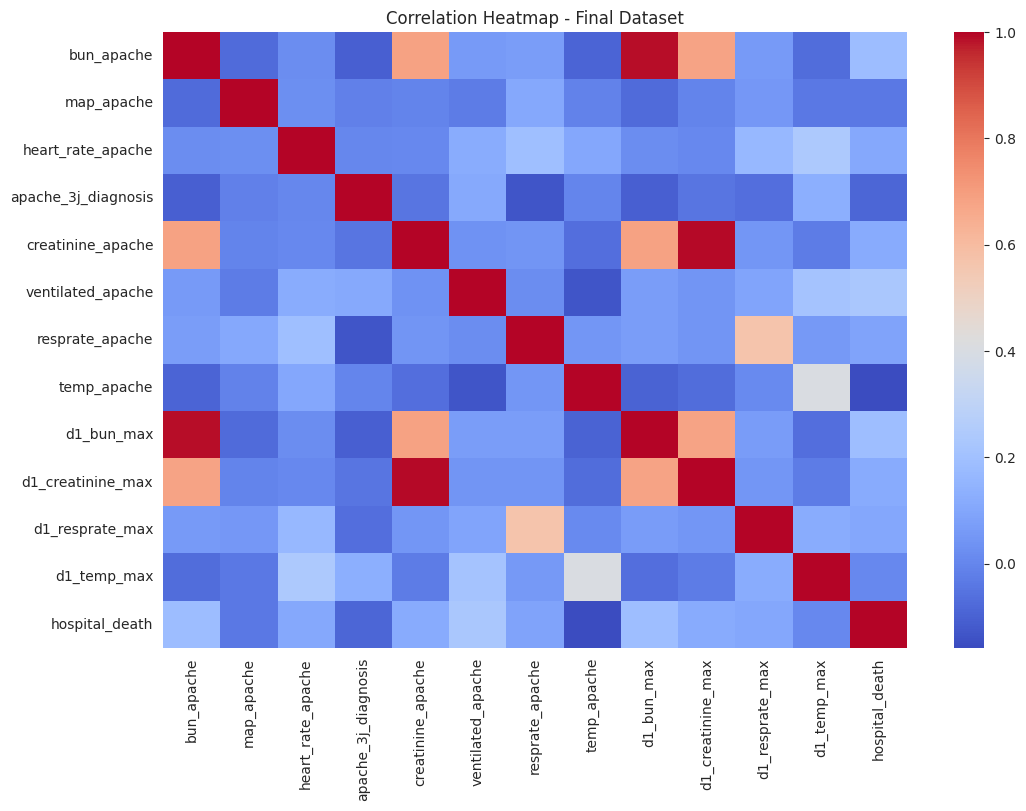

In [34]:
# Correlation heatmap for final dataset
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap - Final Dataset")
plt.show()

### Interpretation

The final dataset is much smaller, more interpretable, and more suitable for machine learning than the original dataset. It retains clinically meaningful variables while reducing dimensionality and excluding leakage-prone features.

Not all selected APACHE variables had direct non-APACHE counterparts, so the final dataset contains fewer non-APACHE features than APACHE features.

## 13. Compare Selected Features with Mortality in Final Dataset

A few selected features are visualized again using the final dataset.

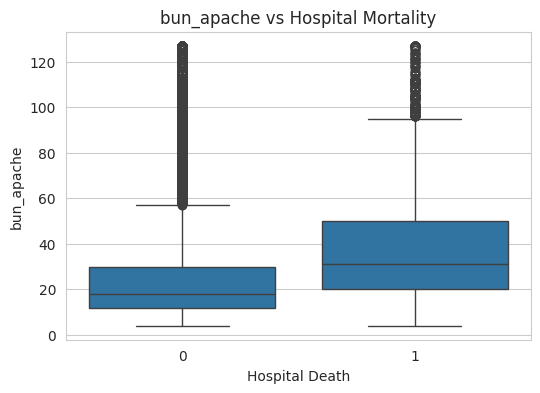

In [35]:
# Boxplot for one APACHE feature in final dataset
plt.figure(figsize=(6, 4))
sns.boxplot(x="hospital_death", y=final_apache[0], data=df_final)
plt.title(f"{final_apache[0]} vs Hospital Mortality")
plt.xlabel("Hospital Death")
plt.ylabel(final_apache[0])
plt.show()

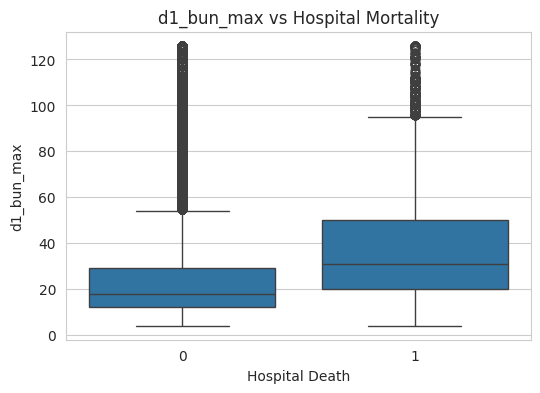

In [36]:
# Boxplot for one non-APACHE counterpart in final dataset
plt.figure(figsize=(6, 4))
sns.boxplot(x="hospital_death", y=final_non_apache[0], data=df_final)
plt.title(f"{final_non_apache[0]} vs Hospital Mortality")
plt.xlabel("Hospital Death")
plt.ylabel(final_non_apache[0])
plt.show()

## 14. Key EDA Findings

The major findings from this exploratory analysis are:

1. The original dataset is high-dimensional and contains substantial missing data.
2. The target variable is imbalanced, with mortality representing a smaller proportion of cases.
3. APACHE variables represent clinically engineered worst-case severity values.
4. Several physiological markers, especially kidney-related features, appear associated with mortality.
5. Random Forest feature importance helped identify the most informative APACHE variables.
6. A final reduced dataset of APACHE features and available physiologically matched non-APACHE features was created.

## 15. Conclusion

This notebook performed exploratory data analysis and data preparation for the ICU mortality prediction project.

The analysis began with the original ICU dataset, examined its structure and missingness, and explored the role of APACHE and non-APACHE variables. A feature selection process using Random Forest was then applied to identify the top APACHE variables. These were paired with clinically corresponding non-APACHE variables to create the final reduced dataset.

This final dataset will be used in the next stage of the project for baseline and machine learning model development.